### Aggregate land regions and add EEZ regions

# Group B: Scenarios of 100% renewable electricity system in Chile

## Shapes

###### Take the GADM dataset to split the country of your choice into at least 5 regions on which all further modelling will built. 
###### If there are more GADM regions, you may aggregate the regions down to that number.
###### For each region determine a representative point (e.g. centroid). 
###### If your country is not landlocked, also extract the shape of the Exclusive Economic Zone.

In [1]:
import gurobipy

In [2]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability
import atlite
import rasterio as rio
from rasterio.plot import show
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import country_converter as coco
import pypsa
import rasterio.crs as crs
import os

In [3]:
# Projection to use for all calculations
# ESRI:102033: South_America_Albers_Equal_Area_Conic
c = "EPSG:4326"

### Splitting Chile into regions

In [4]:
new_directory = r'C:\Users\alex-\Desktop\DSEM\Assignment 5\desesm-group-assignment-main'
os.chdir(new_directory)
url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fgadm&files=gadm_410-levels-ADM_1-CHL.gpkg"
chile_regions = gpd.read_file(url)
chile_regions.drop(["GID_0", "GID_1", "COUNTRY"],axis=1)
chile_regions = chile_regions.to_crs(c)

In [5]:
from sklearn.cluster import AgglomerativeClustering

In [6]:
def aggregate_regions(geodataframe, num_regions):
    # use clustering algorithms K-means to create clusters
    ## extract coordinates for KMeans clustering
    coords = np.array(list(geodataframe.geometry.centroid.apply(lambda point: [point.x, point.y])))
    ## create clusters of regions
    # Create clusters of regions using Agglomerative Clustering
    agglomerative = AgglomerativeClustering(n_clusters=num_regions)
    geodataframe["cluster"] = agglomerative.fit_predict(coords)

    # aggregate regions by clusters
    geodataframe = geodataframe.dissolve(by="cluster")
    geodataframe.NAME_1 =  [
    "Southern Chile",
    'Atacama',
    'Central Chile incl. Santiago',
    'Central Northern Chile',
    'Central Southern Chile'
]
    geodataframe = geodataframe.loc[:, ["NAME_1", "geometry"]].set_index('NAME_1')
    
    return geodataframe

In [7]:
aggregated_regions = aggregate_regions(chile_regions.to_crs(c), 5)

C:\Users\alex-\AppData\Local\Temp\ipykernel_44304\4112780891.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  coords = np.array(list(geodataframe.geometry.centroid.apply(lambda point: [point.x, point.y])))


In [8]:
aggregated_regions

,geometry
NAME_1,
Southern Chile,"MULTIPOLYGON (((-75.61368 -49.85324, -75.61456..."
Atacama,"MULTIPOLYGON (((-70.69997 -25.89342, -70.70020..."
Central Chile incl. Santiago,"MULTIPOLYGON (((-109.45240 -27.20056, -109.452..."
Central Northern Chile,"MULTIPOLYGON (((-71.53570 -32.16451, -71.53576..."
Central Southern Chile,"MULTIPOLYGON (((-74.73901 -43.52268, -74.73918..."


In [9]:
def get_country_economic_zone(EEZ, country):
    """extract the Exclusive Economic Zone (EEZ) for a chosen country
    INPUT:  EEZ                 - GeoDataFrame of EEZ
            country             - Name of the country in string
    OUTPUT: gpd.GeoDataFrame    - GeoDataFrame of the country's EEZ
    """
    return EEZ.query(f"SOVEREIGN1 == '{country}'")

In [10]:
# load Exclusive economic zones
url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fmarineregions%2FWorld_EEZ_v11_20191118_gpkg&files=eez_boundaries_v11.gpkg"
EEZ_boundaries = gpd.read_file(url)
EEZ = gpd.read_file("./data/EEZ.gpkg")

In [11]:
# Exclusive economic zone of Chile
## extract Chile's EEZ
chile_EEZ = get_country_economic_zone(EEZ, "Chile").to_crs(c)
chile_EEZ = chile_EEZ.rename(columns = {"GEONAME":"NAME_1"}).loc[:, ["NAME_1", "geometry"]].set_index("NAME_1")

In [12]:
#Removing Easter Island
chile_EEZ = chile_EEZ.iloc[:-1]

In [13]:
chile_regions = pd.concat([chile_regions.to_crs(c), chile_EEZ.to_crs(c)])
# drop 2 islands of EEZ


# update the last row for 1 Chile EEZ
chile_regions.loc[chile_regions.index[-1], 'NAME_1'] = "Chilean Exclusive Economic Zone"
chile_regions.drop(chile_regions[chile_regions["NAME_1"] == "Chilean Exclusive Economic Zone"].index, inplace=True)

In [14]:
## combine Chile aggregated regions and EEZ
aggregated_regionsEEZ = pd.concat([aggregated_regions, chile_EEZ])

In [15]:
aggregated_regionsEEZ

,geometry
NAME_1,
Southern Chile,"MULTIPOLYGON (((-75.61368 -49.85324, -75.61456..."
Atacama,"MULTIPOLYGON (((-70.69997 -25.89342, -70.70020..."
Central Chile incl. Santiago,"MULTIPOLYGON (((-109.45240 -27.20056, -109.452..."
Central Northern Chile,"MULTIPOLYGON (((-71.53570 -32.16451, -71.53576..."
Central Southern Chile,"MULTIPOLYGON (((-74.73901 -43.52268, -74.73918..."
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-70.93199 -54.75580, -70.92427..."
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),"MULTIPOLYGON (((-76.15513 -26.28253, -76.15475..."


In [16]:
chile_regions1 = pd.concat([chile_regions.to_crs(c), chile_EEZ.to_crs(c)])
# drop 2 islands of EEZ
chile_regions1.drop(chile_regions1.tail(2).index,inplace=True) 
chile_regions1 = chile_regions1.reset_index()

# update the last row for 1 Chile EEZ
chile_regions1.loc[chile_regions1.index[-1], 'index'] = 16
chile_regions1.loc[chile_regions1.index[-1], 'GID_0'] = "CHL"
chile_regions1.loc[chile_regions1.index[-1], 'GID_1'] = "CHL.17_1"
chile_regions1.loc[chile_regions1.index[-1], 'COUNTRY'] = "Chile"
chile_regions1.loc[chile_regions1.index[-1], 'NAME_1'] = "Chilean Exclusive Economic Zone"
chile_regions1.drop(chile_regions1[chile_regions1["NAME_1"] == "Chilean Exclusive Economic Zone"].index, inplace=True)

#### # Create converter DF: 

In [17]:
# Create converter DF: 
regions_converter = gpd.sjoin(chile_regions1,aggregated_regions,how="left",op="within")

regions_converter = regions_converter.drop(["GID_0", "GID_1", "COUNTRY"],axis=1)
regions_converter.rename(columns={'NAME_1': 'Regions'}, inplace=True)
regions_converter.reset_index(inplace=True)
regions_converter.rename(columns={'index_right': 'aggRegions'}, inplace=True)

regions_converter = regions_converter.drop(["level_0", "index"],axis=1)

c:\Users\alex-\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


### Renewables

In [41]:
from atlite.gis import ExclusionContainer
from atlite.gis import shape_availability

In [42]:
url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2F&files=country_shapes.geojson"
country_shapes = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2F&files=country_shapes.geojson"
roads = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2F&files=ne_10m_roads.gpkg"
airports = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2F&files=ne_10m_airports.gpkg"
natural_protection_areas = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fwdpa&files=WDPA_Oct2022_Public_shp-CHL.tif"
elevation = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=%2Fgebco&files=GEBCO_2014_2D-CL.nc"
land_cover = "./data/land_cover.tif"

In [1368]:
# Shape of Chile
CHL = gpd.read_file(country_shapes).set_index('name').query("name == 'CL'").to_crs(c).geometry

# Shapes for onshore, offshore and solar
shape_onshore = CHL.geometry 

shape_solar = CHL.geometry

shape_offshore = chile_EEZ.geometry # within EEZ


In [1369]:
aggregated_regions

,geometry
NAME_1,
Southern Chile,"MULTIPOLYGON (((-75.61368 -49.85324, -75.61456..."
Atacama,"MULTIPOLYGON (((-70.69997 -25.89342, -70.70020..."
Central Chile incl. Santiago,"MULTIPOLYGON (((-109.45240 -27.20056, -109.452..."
Central Northern Chile,"MULTIPOLYGON (((-71.53570 -32.16451, -71.53576..."
Central Southern Chile,"MULTIPOLYGON (((-74.73901 -43.52268, -74.73918..."


In [1370]:
shape_CL1 = aggregated_regions.query("NAME_1 == 'CL1'").to_crs(4326).geometry
shape_CL2 = aggregated_regions.query("NAME_1 == 'CL2'").to_crs(4326).geometry
shape_CL3 = aggregated_regions.query("NAME_1 == 'CL3'").to_crs(4326).geometry
shape_CL4 = aggregated_regions.query("NAME_1 == 'CL4'").to_crs(4326).geometry
shape_CL5 = aggregated_regions.query("NAME_1 == 'CL5'").to_crs(4326).geometry

#### Land Eligibility Analysis:

In [1371]:
def plot_area(masked, transform, shape, x, y, subplots=0):
    fig, ax = plt.subplots(figsize=(x,y))
    ax = show(masked, transform=transform, cmap='Greens', vmin=0, ax=ax)
    shape.plot(ax=ax, edgecolor='k', color='None', linewidth=1)

In [1372]:
def area(masked, excluder, shape):
    excluder_float = float(excluder.res**2)
    return masked.sum() * excluder_float / shape.geometry.area * 100

### Onshore:

In [1373]:
excluder_onshore = ExclusionContainer(crs=c)
# 300m distance to major roads
excluder_onshore.add_geometry(roads, buffer=300)
# 10km distance to airports
excluder_onshore.add_geometry(airports, buffer=10000)
# No natural protection areas
excluder_onshore.add_raster(natural_protection_areas, crs=4326)
# Maximum elevation of 2000m
excluder_onshore.add_raster(elevation, codes=lambda x: x>2000, crs=4326)

# 1000m distance to built up areas (i.e. urban land cover class code 50)
excluder_onshore.add_raster(land_cover, codes=[50], buffer=1000, crs=4326)

# Analysis on suitable land cover classes (based on Copernicus document)
## The land cover classes suitable for onshore wind would generally exclude 
## urban, forested (closed forest), agricultural areas with dense canopy, and wetlands, 
## favoring open, non-protected areas.
## Therefore, exclude these code classes 111, 113, 112, 114, 115, 116, 20, 90, 50, 70, 80, 200
excluder_onshore.add_raster(land_cover, codes=[111, 113, 112, 114, 115, 116, 20, 90, 50, 70, 80, 200], buffer=100, crs=32719) 


In [1374]:
# calculate available area for onshore wind in single regions
masked_onshore_regions = []
transform_onshore_regions = []
for i in range(0, 5):
    masked_onshore, transform_onshore = shape_availability(gpd.GeoSeries(aggregated_regions.iloc[i], crs=c), excluder_onshore)
    masked_onshore_regions.append(masked_onshore)
    transform_onshore_regions.append(transform_onshore)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\gis.py:508: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometry = geometry.buffer(d["buffer"])
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: 

In [1375]:
masked_onshore_regions

[array([[False]]),
 array([[False]]),
 array([[False, False]]),
 array([[False]]),
 array([[False]])]

### Offshore:

In [1635]:
chile_EEZ

,geometry
NAME_1,
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-70.93199 -54.75580, -70.92427..."


In [1641]:
### Offshore:
excluder_offshore = ExclusionContainer(crs=c)

# No natural protection areas
excluder_offshore.add_raster(natural_protection_areas, crs=4326)

# 10 km minimum distance to shore
excluder_offshore.add_geometry(CHL, buffer=10000)

# Up to water depth of 50m
excluder_offshore.add_raster(elevation, codes=lambda x: x<-50, crs=4326)

In [1642]:
chile_EEZ = chile_EEZ.to_crs(c)

In [1643]:
masked_offshore, transform_offshore = shape_availability(chile_EEZ, excluder_offshore)

fig, ax = plt.subplots(figsize=(5,5))
ax = show(masked_offshore, transform=transform_offshore, cmap = 'Blues', vmin=0, ax=ax)
shape_offshore.plot(ax=ax, edgecolor='k', color='None', linewidth=0.3)


C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\gis.py:508: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometry = geometry.buffer(d["buffer"])
C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\rasterio\features.py:328: ShapeSkipWarning: Invalid or empty shape geometry at index 0 will not be rasterized.
  warnings.warn('Invalid or empty shape {} at index {} will not be rasterized.'.format(geom, index), ShapeSkipWarning)


ValueError: No valid geometry objects found for rasterize

In [1637]:
# OFFSHORE WIND
masked_offshore_regions = []
transform_offshore_regions = []
for i in chile_EEZ.index:
    masked_onshore, transform_onshore = shape_availability(gpd.GeoSeries(chile_EEZ.loc[i], crs=c), excluder_offshore)
    masked_offshore_regions.append(masked_onshore)
    transform_offshore_regions.append(transform_onshore)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\gis.py:508: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometry = geometry.buffer(d["buffer"])
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: Invalid latitude'
INFO:rasterio._env:GDAL signalled an error: err_no=1, msg='PROJ: moll: 

### Solar:

In [ ]:
excluder_solar = None
excluder_solar = ExclusionContainer(crs=4326)

# Natural protection areas
excluder_solar.add_raster(natural_protection_areas, crs=4326)

# Analysis on suitable land cover classes
## The land cover classes suitable for solar (rooftop and utility) would generally exclude 
## forested, agricultural areas with dense canopy, and wetlands, 
## favoring open, non-protected areas.
## Therefore, exclude these code classes 111, 113, 112, 114, 115, 116, 121, 123, 122, 124, 125, 126, 20, 90, 70, 80, 200

excluder_solar.add_raster(land_cover, codes=[111, 113, 112, 114, 115, 116, 121, 123, 122, 124, 125, 126, 20, 90, 70, 80, 200], buffer=100, crs=4326)

In [ ]:
# calculate available area for onshore wind in single regions
masked_solar_regions = []
transform_solar_regions = []
for i in range(0, 5):
    masked_solar, transform_solar = shape_availability(gpd.GeoSeries(aggregated_regions.iloc[i], crs=c), excluder_solar)
    masked_solar_regions.append(masked_onshore)
    transform_solar_regions.append(transform_onshore)

### Weather Data

In [ ]:
minx, miny, maxx, maxy = chile_regions.total_bounds
buffer = 0.25

In [ ]:
import atlite
cutout = atlite.Cutout("./data/cutout-2013-era5.nc")

### Onshore wind - Vestast V112 3MW

In [ ]:
aggregated_regions.geometry = gpd.GeoSeries(aggregated_regions["geometry"], crs=c)

In [ ]:
aggregated_regions[0:5].index

Index(['CHL1', 'CHL2', 'CHL3', 'CHL4', 'CHL5'], dtype='object', name='NAME_1')

In [ ]:
A = cutout.availabilitymatrix(aggregated_regions[0:5].geometry, excluder_onshore)

Compute availability matrix: 100%|██████████| 5/5 [05:26<00:00, 65.27s/ gridcells]


In [ ]:
# For both wind and solar, assume a deployment density of 3 MW/km2
cap_per_sqkm = 3 # MW/km2
area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6
area = xr.DataArray(area, dims=('spatial'))
onshore_capacity_matrix = A.stack(spatial=["y", "x"]) * area * cap_per_sqkm

C:\Users\alex-\AppData\Local\Temp\ipykernel_39000\3641957331.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6


In [ ]:
wind = cutout.wind(
    atlite.windturbines.Vestas_V112_3MW,
    matrix=onshore_capacity_matrix,
    index=aggregated_regions[0:5].index,
    per_unit=True,
)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\resource.py:72: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.13.
  warnings.warn(msg, FutureWarning)


[########################################] | 100% Completed | 215.74 s


In [ ]:
wind = wind.to_pandas()
wind.to_csv("./data/A_Wind", index=False)

### Solar panel - CdTe

In [ ]:
solar_regions = chile_regions[0:15]

In [ ]:
A_solar = cutout.availabilitymatrix(unshore_regions, excluder_solar)

Compute availability matrix:   0%|          | 0/15 [00:00<?, ? gridcells/s]

Compute availability matrix: 100%|██████████| 15/15 [00:25<00:00,  1.68s/ gridcells]


In [ ]:
solar_regions.index

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], dtype='object')

In [ ]:
capacity_matrix_solar = A_solar.stack(spatial=['y', 'x']) * area * cap_per_sqkm

In [ ]:
'''pv = cutout.pv(
    panel=atlite.solarpanels.CdTe,
    matrix=capacity_matrix_solar,
    orientation='latitude_optimal',
    index=solar_regions.index,
    per_unit=True,
)'''

"pv = cutout.pv(\n    panel=atlite.solarpanels.CdTe,\n    matrix=capacity_matrix_solar,\n    orientation='latitude_optimal',\n    index=solar_regions.index,\n    per_unit=True,\n)"

In [ ]:
# capacity factor time series of solar
df_pv = pv.to_pandas()

NAME_1,CHL1,CHL2,CHL3,CHL4,CHL5
time,,,,,
2013-01-01 00:00:00,0.060006,0.000019,0.018331,0.006247,0.029967
2013-01-01 01:00:00,0.016625,0.000000,0.000135,0.000000,0.000011
2013-01-01 02:00:00,0.000000,0.000000,0.000022,0.000000,0.000000
2013-01-01 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
2013-01-01 04:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...
2013-12-31 19:00:00,0.451974,0.762323,0.809928,0.839488,0.365366
2013-12-31 20:00:00,0.445929,0.626014,0.702470,0.731086,0.341919
2013-12-31 21:00:00,0.383134,0.474408,0.555481,0.558563,0.310579


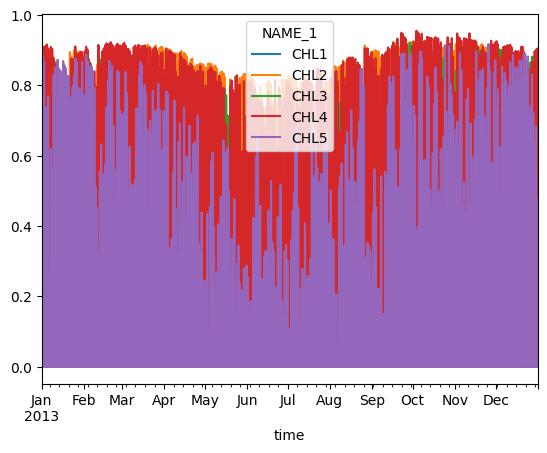

In [ ]:
df_pv.plot()
df_pv.to_csv("./data/A_Solar", index=False)

### Offshore wind - NREL ReferenceTurbine 5MW offshore

In [ ]:
aggregated_regions.iloc[5:8]

,geometry
NAME_1,
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-808425.879 -2504985.792, -807..."
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),"MULTIPOLYGON (((-1528105.804 584286.120, -1527..."
Chilean Exclusive Economic Zone (Easter Island),"MULTIPOLYGON (((-4329434.259 383144.671, -4329..."


In [ ]:
### Offshore wind - NREL ReferenceTurbine 5MW offshore
offhore_region = aggregated_regions.iloc[5:8]
offhore_region

,geometry
NAME_1,
Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-808425.879 -2504985.792, -807..."
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),"MULTIPOLYGON (((-1528105.804 584286.120, -1527..."
Chilean Exclusive Economic Zone (Easter Island),"MULTIPOLYGON (((-4329434.259 383144.671, -4329..."


In [ ]:
'''A_offshore = cutout.availabilitymatrix(offhore_region, excluder_offshore)'''

'A_offshore = cutout.availabilitymatrix(offhore_region, excluder_offshore)'

In [ ]:
# For both wind and solar, assume a deployment density of 3 MW/km2
cap_per_sqkm = 3 # MW/km2
area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6
area = xr.DataArray(area, dims=('spatial'))
offshore_capacity_matrix = A_offshore.stack(spatial=["y", "x"]) * area * cap_per_sqkm

C:\Users\alex-\AppData\Local\Temp\ipykernel_39000\816470729.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area = cutout.grid.set_index(['y', 'x']).to_crs(4326).area / 1e6


In [ ]:
windoffshore = cutout.wind(
    atlite.windturbines.NREL_ReferenceTurbine_5MW_offshore,
    matrix=offshore_capacity_matrix,
    index=offhore_region.index,
    per_unit=True,
)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\atlite\resource.py:72: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.13.
  warnings.warn(msg, FutureWarning)


[########################################] | 100% Completed | 214.59 s


In [ ]:
# capacity factor time series of solar
df_offshore = windoffshore.to_pandas()

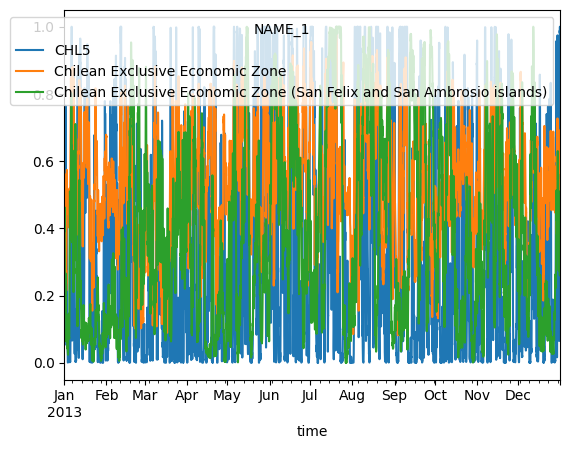

In [ ]:
df_offshore.plot()
df_offshore.to_csv("./data/A_Offshore", index=False)

## Adding Generators

### Add Power  Plants

In [18]:
# Add the fleet of existing power plants
pwp = pd.read_csv(".\data\global_power_plant_database.csv", index_col=0, parse_dates=True)

# Power plants in Chile
geometry = gpd.points_from_xy(pwp["longitude"], pwp["latitude"])
pwp_gdf = gpd.GeoDataFrame(pwp, geometry=geometry, crs=c)
pwp_chile = pwp_gdf.query("country_long =='Chile'")
pwp_chile = pwp_chile.set_geometry('geometry')

# Disregard existing wind and solar capacities
pwp_chile = pwp_chile[~pwp_chile['primary_fuel'].isin(['Wind', 'Solar'])]


aggregated_regions = gpd.GeoDataFrame(aggregated_regions,geometry="geometry")
regions_converter = regions_converter.to_crs(c)
pwp_chile = pwp_chile .to_crs(c)

### Joining Powerplant, Cost and Geographic DataFrames
# 14 regions
pwp_chile = gpd.sjoin(pwp_chile,chile_regions, how='left', op='within')
pwp_chile["p_max_pu"] = pwp_chile.estimated_generation_gwh_2017*(1e3)/8760/pwp_chile.capacity_mw


### Aggregate fossil power plants over different plants of the same type
pwp_chile_filtered = pwp_chile[pwp_chile['p_max_pu'] > 0]

grouped_sum = pd.DataFrame(pwp_chile_filtered.groupby(["NAME_1", "primary_fuel"])["capacity_mw"].transform('sum'))
pwp_chile_filtered.set_index(["NAME_1","primary_fuel"],inplace=True)
grouped_sum.index = pwp_chile_filtered.index

grouped_sum.drop_duplicates(inplace=True)
grouped_sum.reset_index(inplace=True)


pwp_chile["Weighted_Regional_Capacity"] = 0
for idx, row in pwp_chile.iterrows():
    if row["capacity_mw"] != 0:
        grouped_sum_1 = grouped_sum[(grouped_sum["NAME_1"] == row["NAME_1"]) & (grouped_sum["primary_fuel"] == row["primary_fuel"])]["capacity_mw"]
        if not grouped_sum_1.empty:
            pwp_chile.at[idx, "Weighted_Regional_Capacity"] = (row["p_max_pu"] * row["capacity_mw"]) / grouped_sum_1.iloc[0]
    else:
        pwp_chile.at[idx, "Weighted_Regional_Capacity"] = 0
        
        
# Aggregate Capacity Factors
aggregated_plants_cf = pwp_chile.groupby(["NAME_1","primary_fuel"])["Weighted_Regional_Capacity"].sum().unstack().fillna(0)
aggregated_plants_capacity = pwp_chile.groupby(["NAME_1","primary_fuel"])["capacity_mw"].sum().unstack().fillna(0)


aggregated_plants_cf.reset_index(inplace=True)
aggregated_plants_capacity.reset_index(inplace=True)

# ### Collapse Aggregated_Plants Data to five region level
aggregated_plants_cf = pd.merge(aggregated_plants_cf, chile_regions1, on="NAME_1", how="inner")
aggregated_plants_capacity = pd.merge(aggregated_plants_capacity, chile_regions1, on="NAME_1", how="inner")

aggregated_plants_cf = gpd.GeoDataFrame(aggregated_plants_cf,geometry=aggregated_plants_cf["geometry"],crs=c)
aggregated_plants_capacity = gpd.GeoDataFrame(aggregated_plants_capacity,geometry=aggregated_plants_capacity["geometry"],crs=c)

aggregated_plants_cf.drop(columns="GID_0",inplace=True)
aggregated_plants_cf.drop(columns="GID_1",inplace=True)
aggregated_plants_cf.drop(columns="index",inplace=True)
aggregated_plants_cf.drop(columns="COUNTRY",inplace=True)
aggregated_plants_capacity.drop(columns="GID_0",inplace=True)
aggregated_plants_capacity.drop(columns="GID_1",inplace=True)
aggregated_plants_capacity.drop(columns="index",inplace=True)
aggregated_plants_capacity.drop(columns="COUNTRY",inplace=True)

aggregated_regions = aggregated_regions.to_crs(c)
# Merge Capacity Factor to Aggregated Regions'
aggregated_plants_cf_merged = gpd.sjoin(aggregated_plants_cf, regions_converter, op='within')
aggregated_plants_capacity_merged = gpd.sjoin(aggregated_plants_capacity, regions_converter, op='within')



aggregated_plants_capacity_merged.drop(columns="Regions",inplace=True)
aggregated_plants_cf_merged.drop(columns="Regions",inplace=True)

# Merge Capacity to 5 Aggregated Regions of Interest
aggregated_plants_capacity_merged = gpd.sjoin(aggregated_plants_capacity, regions_converter, op='within')

aggregated_plants_capacity_merged = aggregated_plants_capacity_merged.drop("Regions",axis=1)

# Melt Capacity
aggregated_plants_capacity_merged = pd.melt(aggregated_plants_capacity_merged, 
                     id_vars=['NAME_1', 'geometry', 'aggRegions'], 
                     var_name='primary_fuel', 
                     value_name='Capacity')

# Melt Capacity Factors
aggregated_plants_cf_merged = pd.melt(aggregated_plants_cf_merged, id_vars=['NAME_1', 'geometry', "aggRegions"],
                    value_vars=['Biomass', 'Coal', 'Gas', 'Hydro', 'Oil', 'Petcoke'],
                    var_name='primary_fuel', value_name='p_max_pu')

aggregated_plants_cf.rename(columns={"NAME_1_right": "NAME_1"}, inplace=True)
aggregated_plants_capacity.rename(columns={"NAME_1_left": "NAME_1"}, inplace=True)

# Aggregating Power Plants on the Aggregated Regions Level
aggregated_plants_merged = pd.merge(aggregated_plants_cf_merged,aggregated_plants_capacity_merged,on=['NAME_1', 'geometry', 'aggRegions', "primary_fuel"], how='inner')

# Calculating Weighted Average Capacity Factors
aggregated_plants_merged["Weighted_Agg_CF"] = 0

grouped_sum = aggregated_plants_merged.groupby(["aggRegions", "primary_fuel"])["Capacity"].transform('sum')
aggregated_plants_merged["Weighted_Agg_CF"] = (aggregated_plants_merged['p_max_pu'] * aggregated_plants_merged['Capacity']) / grouped_sum

aggregated_plants_merged["Weighted_Agg_CF"] = (
    aggregated_plants_merged['p_max_pu'] * aggregated_plants_merged['Capacity'] /
    grouped_sum.where(grouped_sum != 0, 1)  # Replace zero with 1 to avoid division by zero
)

# Collapse the CF DataFrame doen to 5 regions of interes
aggregated_cf = pd.DataFrame(aggregated_plants_merged.groupby(["aggRegions", "primary_fuel"])["Weighted_Agg_CF"].sum().unstack())
aggregated_capacity = aggregated_plants_capacity_merged.groupby(["aggRegions", "primary_fuel"])["Capacity"].sum().unstack()

aggregated_cf.reset_index("aggRegions",inplace=True)
aggregated_capacity.reset_index("aggRegions",inplace=True)

aggregated_capacity = pd.melt(aggregated_capacity, id_vars="aggRegions",
                                     value_vars=['Biomass', 'Coal', 'Gas', 'Hydro', 'Oil', 'Petcoke'],
                                     var_name='primary_fuel', value_name='Capacity')

aggregated_cf = pd.melt(aggregated_cf, id_vars="aggRegions",
                                     value_vars=['Biomass', 'Coal', 'Gas', 'Hydro', 'Oil', 'Petcoke'],
                                     var_name='primary_fuel', value_name='Capacity Factor')
aggregated_cf.set_index(["aggRegions", "primary_fuel"],inplace=True)
aggregated_capacity.set_index("aggRegions",inplace=True)

C:\Users\alex-\AppData\Local\Temp\ipykernel_44304\954479212.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  pwp = pd.read_csv(".\data\global_power_plant_database.csv", index_col=0, parse_dates=True)
C:\Users\alex-\AppData\Local\Temp\ipykernel_44304\954479212.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pwp = pd.read_csv(".\data\global_power_plant_database.csv", index_col=0, parse_dates=True)
c:\Users\alex-\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):
c:\Users\alex-\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecate

## Preparing the model

### Determine the centroids per region

In [19]:
aggregated_regionsEEZ.reset_index(inplace=True)

In [20]:
aggregated_regionsEEZ = aggregated_regionsEEZ.rename(columns={"Name_1":"aggRegions"})

In [21]:
aggregated_regionsEEZ

,NAME_1,geometry
0,Southern Chile,"MULTIPOLYGON (((-75.61368 -49.85324, -75.61456..."
1,Atacama,"MULTIPOLYGON (((-70.69997 -25.89342, -70.70020..."
2,Central Chile incl. Santiago,"MULTIPOLYGON (((-109.45240 -27.20056, -109.452..."
3,Central Northern Chile,"MULTIPOLYGON (((-71.53570 -32.16451, -71.53576..."
4,Central Southern Chile,"MULTIPOLYGON (((-74.73901 -43.52268, -74.73918..."
5,Chilean Exclusive Economic Zone,"MULTIPOLYGON (((-70.93199 -54.75580, -70.92427..."
6,Chilean Exclusive Economic Zone (San Felix and...,"MULTIPOLYGON (((-76.15513 -26.28253, -76.15475..."


In [22]:
aggregated_points = aggregated_regionsEEZ.copy()
aggregated_points = aggregated_points.representative_point()
aggregated_points = aggregated_points.to_crs(c).reset_index()
aggregated_points.columns.values[1] = "geometry"
aggregated_points["longitude"] = aggregated_points["geometry"].x
aggregated_points["latitude"] = aggregated_points["geometry"].y
aggregated_points.index = aggregated_regionsEEZ["NAME_1"]

In [23]:
aggregated_points

,index,geometry,longitude,latitude
NAME_1,,,,
Southern Chile,0,POINT (-73.44280 -48.76710),-73.442796,-48.767099
Atacama,1,POINT (-69.10543 -21.78034),-69.105432,-21.780341
Central Chile incl. Santiago,2,POINT (-71.48813 -35.25663),-71.488130,-35.256635
Central Northern Chile,3,POINT (-70.54188 -28.78394),-70.541877,-28.783937
Central Southern Chile,4,POINT (-72.89906 -40.82439),-72.899056,-40.824395
Chilean Exclusive Economic Zone,5,POINT (-75.69557 -39.10151),-75.695574,-39.101509
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),6,POINT (-79.99087 -26.31814),-79.990871,-26.318140


In [24]:
aggregated_points.reset_index(inplace=True)
aggregated_points.rename(columns={"NAME_1":"aggRegions"},inplace=True)
aggregated_points.set_index("aggRegions",inplace=True)

In [25]:
aggregated_points = aggregated_points.drop("index",axis=1)

In [26]:
aggregated_points

,geometry,longitude,latitude
aggRegions,,,
Southern Chile,POINT (-73.44280 -48.76710),-73.442796,-48.767099
Atacama,POINT (-69.10543 -21.78034),-69.105432,-21.780341
Central Chile incl. Santiago,POINT (-71.48813 -35.25663),-71.488130,-35.256635
Central Northern Chile,POINT (-70.54188 -28.78394),-70.541877,-28.783937
Central Southern Chile,POINT (-72.89906 -40.82439),-72.899056,-40.824395
Chilean Exclusive Economic Zone,POINT (-75.69557 -39.10151),-75.695574,-39.101509
Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands),POINT (-79.99087 -26.31814),-79.990871,-26.318140


In [27]:
aggregated_points.index = aggregated_points.index.to_series().replace({
    'Chilean Exclusive Economic Zone': 'EEZ',
    'Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands)': 'EEZ (San Felix and San Ambrosio)'
})

aggregated_regionsEEZ.reset_index(inplace=True)

In [28]:
aggregated_points

,geometry,longitude,latitude
aggRegions,,,
Southern Chile,POINT (-73.44280 -48.76710),-73.442796,-48.767099
Atacama,POINT (-69.10543 -21.78034),-69.105432,-21.780341
Central Chile incl. Santiago,POINT (-71.48813 -35.25663),-71.488130,-35.256635
Central Northern Chile,POINT (-70.54188 -28.78394),-70.541877,-28.783937
Central Southern Chile,POINT (-72.89906 -40.82439),-72.899056,-40.824395
EEZ,POINT (-75.69557 -39.10151),-75.695574,-39.101509
EEZ (San Felix and San Ambrosio),POINT (-79.99087 -26.31814),-79.990871,-26.318140


### Preparing Distances for Transmission Lines

In [29]:
regions = aggregated_regions[['geometry']]
index_values = regions.index[1]

points = regions.representative_point() # Finding representative points
points = points.to_crs("ESRI:102033")
distances = pd.concat({k: points.distance(p) for k, p in points.items()}, axis=1).div(1e3)

dict = {1: 'Region 1',
        2: 'Region 2',
        3: 'Region 3',
        4: 'Region 4',
        5: 'Region 5',}

distances.rename(columns=dict, inplace=True)
distances.rename(index=dict, inplace=True)
distances.reset_index(inplace=True)
distances.rename(columns={'NAME_1': 'aggRegion'}, inplace=True)
distances = distances.melt(id_vars='aggRegion', var_name='destination', value_name='distance')

distances = distances.loc[(distances["aggRegion"].str.contains("Atacama")) & (distances["destination"].str.contains("Central Northern Chile")) |
            (distances["aggRegion"].str.contains("Central Northern Chile")) & (distances["destination"].str.contains("Central Chile incl. Santiago")) |
              (distances["aggRegion"].str.contains("Central Chile incl. Santiago")) & (distances["destination"].str.contains("Central Southern Chile")) |
               (distances["aggRegion"].str.contains("entral Southern Chile")) & (distances["destination"].str.contains("Southern Chile"))]

# Creating the nested dictionary
nested_dict = {}
for index, row in distances.iterrows():
    region = row['aggRegion']
    destination = row['destination']
    distance = row['distance']
    
    if region not in nested_dict:
        nested_dict[region] = {}
    
    nested_dict[region][destination] = distance

print(nested_dict)

{'Central Southern Chile': {'Southern Chile': 864.0825189206818, 'Central Southern Chile': 0.0}, 'Central Northern Chile': {'Central Chile incl. Santiago': 754.8126387801974}, 'Atacama': {'Central Northern Chile': 828.7930288722002}, 'Central Chile incl. Santiago': {'Central Southern Chile': 643.4968808948424}}


### Preparing Population and Regional Demand


In [30]:
population = {
    "Antofagasta": 641, "Araucanía": 1002, "Arica y Parinacota": 247,
    "Atacama": 321, "Aysén del General Ibañez del Cam": 110, "Bío-Bío": 2141,
    "Coquimbo": 794, "Libertador General Bernardo O'HÄi": 935, "Los Lagos": 845,
    "Los Ríos": 410, "Magallanes y Antártica Chilena": 166, "Maule": 1058, "Santiago Metropolitan": 7483,
    "Tarapacá": 353, 
    "Valparaíso": 1860, "Nuble": 480, "Los Ríos": 384
}
popdf = pd.DataFrame(list(population.items()), columns=['Region', 'Population'])
total_population_2013 = popdf["Population"].sum()

# Future Population in 1000 https://www.populationpyramid.net/chile/2017/
popest = {"2017":18368, "2020": 19300, "2030":19869, "2040":20600, "2050":20675}
popestdf = pd.DataFrame(list(popest.items()), columns=["Year", "Population"])
popestdf["Pop_growth"] = popestdf["Population"] /total_population_2013
popestdf.set_index("Year",inplace=True)


population = pd.DataFrame.from_dict(population, orient="index", columns=["regional_population"])

population["percentage"] = population["regional_population"] / population["regional_population"].sum() * 100
population.reset_index(inplace=True)
population.rename(columns={'index': 'NAME_1'}, inplace=True)
population.rename(columns={'NAME_1': 'Regions'}, inplace=True)
population = regions_converter.merge(population, on="Regions",how="right")
population = population.groupby("aggRegions").agg({"percentage": "sum", "regional_population": "sum"})
population["percentage"] = population["percentage"].round()

### Loading Load Data

In [31]:
fn="./data/load.csv"
resolution = 3
ts = pd.read_csv(fn,index_col="time")
ts.index = pd.to_datetime(ts.index)
ts = ts["CL"]
ts = ts.to_frame()
tsindex = ts.index
tsindex = pd.to_datetime(tsindex)
tsindex= tsindex

for i in range(len(population)):
      ts[population.index[i]] = ts["CL"].values * population.iloc[i,0]/100

ts = ts.drop(columns='CL')
ts.head()

,Atacama,Central Chile incl. Santiago,Central Northern Chile,Central Southern Chile,Southern Chile
time,,,,,
2013-01-01 00:00:00,859.147564,6995.915879,736.412198,1472.824396,122.735366
2013-01-01 01:00:00,843.823687,6871.135739,723.277446,1446.554892,120.546241
2013-01-01 02:00:00,809.979050,6595.543696,694.267757,1388.535515,115.711293
2013-01-01 03:00:00,750.060844,6107.638301,642.909295,1285.818590,107.151549
2013-01-01 04:00:00,692.116471,5635.805547,593.242689,1186.485378,98.873782


### Preparing OffhosreOffshore and Onshore Series

<Axes: xlabel='time'>

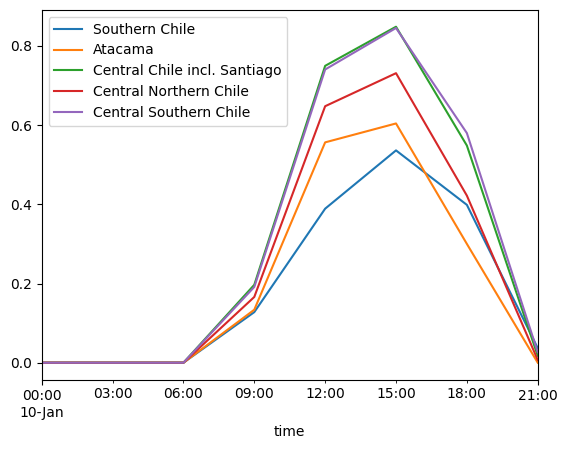

In [32]:
### Offshore Wind
fn="./data/A_Offshore.csv"
tsOffshore = pd.read_csv(fn)
tsOffshore.index = pd.to_datetime(tsindex)
tsOffshore.index = tsOffshore.index - pd.Timedelta(hours=3)
tsOffshore = tsOffshore.resample(f"{resolution}h").first()

column_mapping = {"Chilean Exclusive Economic Zone":"EEZ", 
                           "Chilean Exclusive Economic Zone (San Felix and San Ambrosio islands)": "EEZ (San Felix and San Ambrosio)" 
}

tsOffshore = tsOffshore.rename(columns=column_mapping)

### Onshore WInd
fn="./data/A_Wind.csv"
tsOnshore = pd.read_csv(fn)
tsOnshore.index = tsindex
tsOnshore.index = pd.to_datetime(tsindex)
tsOnshore.index = tsOnshore.index - pd.Timedelta(hours=3)

column_mapping = {
    'CHL1': 'Southern Chile',
    'CHL2': 'Atacama',
    'CHL3': 'Central Chile incl. Santiago',
    'CHL4': 'Central Northern Chile',
    'CHL5': 'Central Southern Chile'
}

tsOnshore = tsOnshore.rename(columns=column_mapping)

# Solar 
fn="./data/A_Solar.csv"
tsSolar = pd.read_csv(fn)
tsSolar.index = pd.DatetimeIndex(tsindex)
tsSolar.index = tsSolar.index - pd.Timedelta(hours=3)
#tsSolar.index = tsSolar.index.tz_localize('America/Santiago', ambiguous=False) #

tsSolar = tsSolar.resample(f"{resolution}h").first()

tsSolar = tsSolar.rename(columns=column_mapping)


tsSolar.loc["2013-01-10"].plot()

### Build the Model

In [34]:
# technology
year = 2020
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "discount rate": 0.07,
    "CO2 intensity": 0,
    "VOM":0,
    "capital_cost":0,
    "FOM":0,
    "investment":0
}
costs = costs.value.unstack().fillna(defaults)

# Petcoke is an oil derivative
costs.at["petcoke", "fuel"] = costs.at["oil", "fuel"]
costs.at["petcoke", "CO2 intensity"] = costs.at["oil", "CO2 intensity"]
costs.at["petcoke", "VOM"] = costs.at["oil", "VOM"]
costs.at["petcoke", "fuel"] = costs.at["oil", "fuel"]



# Annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


# Marginal cost,  €/MWh
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"] 





# Capital cost, €/MW/a
annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]






### Build the model
n = pypsa.Network()
# Add buses with locations according to representative points
for i, row in aggregated_points.iterrows():
    n.add("Bus", i, x=row["geometry"].x, y=row["geometry"].y)




# add generators to model
for region, row in aggregated_capacity.iterrows():
        primary_fuel = row["primary_fuel"]
        capacity = row["Capacity"]
        tech = row["primary_fuel"]
        if ((capacity != 0) & (aggregated_cf.at[(region, primary_fuel), 'Capacity Factor']!=0)):
                        n.add("Generator",
                        f"{region} {tech}",
                        bus=region,
                        carrier=primary_fuel,
                        efficiency= costs.at[primary_fuel.lower(),"efficiency"],
                        p_nom=capacity,  
                        capital_cost=0,
                        p_max_pu =aggregated_cf.at[(region, primary_fuel), 'Capacity Factor'],
                        p_nom_extendable=False
                        )

# Adding Links
for start in nested_dict.keys():
    for destination,distance in nested_dict[start].items():
        if distance!=0:
            n.add(
                "Link",
                f"{start}-{destination}",
                bus0=f"{start}",
                bus1=f"{destination}",
                efficiency=1,
                marginal_cost=0,
                p_min_pu=-1,
                length=distance* 1.5,
                capital_cost=400 * distance * 1.5,
                p_nom_extendable=True,
            )
             
# Adding Links to offshore            
start = "EEZ"
destination = "Central Chile incl. Santiago"

n.add(
   "Link",
   "Chile EEZ Offshore - Central Chile incl. Santiago",
    bus0=f"{start}",
    bus1=f"{destination}",
    efficiency=1,
    marginal_cost=0,
    p_min_pu=0,
    length=0,
    capital_cost=0,
    p_nom_extendable=True,
    carrier="HVAC"
)

start = "EEZ"
destination = "Central Southern Chile"

n.add(
   "Link",
   f"{start}-{destination}",
    bus0=f"{start}",
    bus1=f"{destination}",
    efficiency=1,
    marginal_cost=0,
    p_min_pu=0,
    length=0,
    capital_cost=0,
    p_nom_extendable=True,
    carrier="HVAC"
)

start = "EEZ"
destination = "Southern Chile"

n.add(
   "Link",
   f"{start}-{destination}",
    bus0=f"{start}",
    bus1=f"{destination}",
    efficiency=1,
    marginal_cost=0,
    p_min_pu=0,
    length=0,
    capital_cost=0,
    p_nom_extendable=True,
    carrier="HVAC"
)
start = "EEZ (San Felix and San Ambrosio)"
destination = "Central Northern Chile"

n.add(
   "Link",
   f"{start}-{destination}",
    bus0=f"{start}",
    bus1=f"{destination}",
    efficiency=1,
    marginal_cost=0,
    p_min_pu=0,
    length=0,
    capital_cost=0,
    p_nom_extendable=True,
    carrier="HVAC"
)

start = "EEZ (San Felix and San Ambrosio)"
destination = "Atacama"

n.add(
   "Link",
   f"{start}-{destination}",
    bus0=f"{start}",
    bus1=f"{destination}",
    efficiency=1,
    marginal_cost=0,
    p_min_pu=0,
    length=0,
    capital_cost=0,
    p_nom_extendable=True,
    carrier="HVAC"
)

### Load Data ###########################################################################################
ts = ts.resample(f"{resolution}h").mean()
tsDict = ts.to_dict(orient="index")


# Adding Snapshots
for timestamp in tsDict.keys():
    for region,load in tsDict[timestamp].items():
        n.add(
            "Load",
            f"Demand {region} {timestamp}",
            bus=f"{region}",
            p_set=load
        )
        
n.set_snapshots(ts.index)
n.snapshot_weightings.loc[:,:] = resolution

# Adding renewables ###########################################################################################
# Adding Offshore
region = "EEZ"
n.add("Generator",
    f"{region} OffWind",
    bus=region,
    carrier="offwind",
    p_max_pu=tsOffshore[region],
    marginal_cost=costs.at["offwind", "VOM"],
    capital_cost=costs.at["offwind", "capital_cost"],
    efficiency=costs.at["offwind", "efficiency"],
    p_min_pu=0
)
    

# Adding Offshore
region = "EEZ (San Felix and San Ambrosio)"
n.add("Generator",
    f"{region} OffWind",
    bus=region,
    carrier="offwind",
    p_max_pu=tsOffshore[region],
    marginal_cost=costs.at["offwind", "VOM"],
    capital_cost=costs.at["offwind", "capital_cost"],
    efficiency=costs.at["offwind", "efficiency"],
    p_min_pu=0
)

## Adding Onshore 
for region, data in tsOnshore.items():
        n.add(
            "Generator",
            f"{region} OnWind",
            bus=region,
            carrier="onwind",
            p_max_pu=tsOnshore[region],
            marginal_cost=costs.at["onwind", "VOM"],
            capital_cost=costs.at["onwind", "capital_cost"],
            efficiency=costs.at["onwind", "efficiency"],
            p_nom_extendable=True,
        )
        
# Adding Solar Power
for region, data in tsSolar.items():
        n.add(
            "Generator",
            f"{region} Solar",
            bus=region,
            carrier="solar",
            p_max_pu=tsSolar[region],
            marginal_cost=costs.at["solar", "VOM"],
            capital_cost=costs.at["solar", "capital_cost"],
            efficiency=costs.at["solar", "efficiency"],
            p_nom_extendable=True,
        )



        
# Adding Battery Storage 
for index, row in aggregated_regions.iterrows():
    n.add(
        "StorageUnit",
        f"{index} battery storage",
        bus=index,
        carrier="battery storage",
        max_hours=6,
        capital_cost=costs.at["battery inverter", "capital_cost"] + 6 * costs.at["battery storage", "capital_cost"],
        efficiency_store=costs.at["battery inverter", "efficiency"],
        efficiency_dispatch=costs.at["battery inverter", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True)
    
    
# Add an option to build hydrogen storage as StorageUnit with an energy-to-power ratio of 336h.
capital_costs = (
    costs.at["electrolysis", "capital_cost"] +
    costs.at["fuel cell", "capital_cost"] +
    336 * costs.at["hydrogen storage underground", "capital_cost"]
)


for index, row in aggregated_regions.iterrows():
    n.add(
        "StorageUnit",
        f"{index} hydrogen storage underground",
        bus=index,
        carrier="hydrogen storage underground",
        max_hours=336,
        capital_cost=capital_costs,
        efficiency_store=costs.at["electrolysis", "efficiency"],
        efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        p_nom_extendable=True,
        cyclic_state_of_charge=True,
)
      


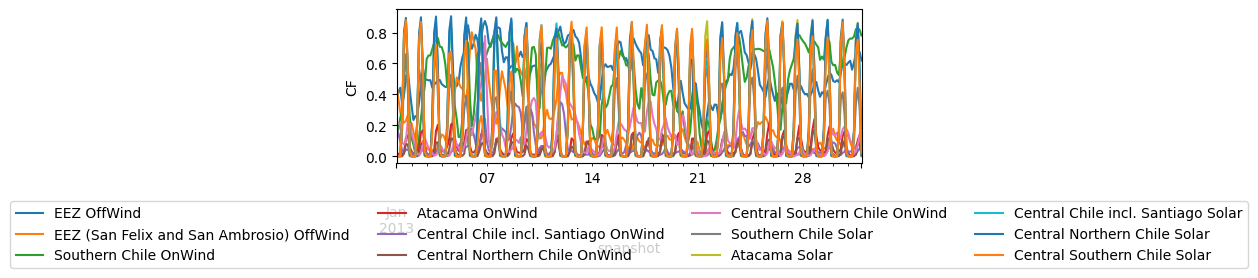

In [35]:
# Assuming n.generators_t.p_max_pu.loc["2013-12"] is your data series
# Plotting the data
ax = n.generators_t.p_max_pu.loc["2013-1"].plot(figsize=(6, 2), ylabel="CF")

# Getting the legend from the plot
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4)  # Modified bbox_to_anchor


# Showing the plot
plt.show()

In [36]:
carriers = ['Biomass', 'Coal', 'Gas', 'Hydro', 'Oil', 'Petcoke', 'offwind', 'onwind', 'solar', "battery storage","hydrogen storage underground"]
colors = ["red", "forestgreen", "black", "orange", "royalblue", "sienna" ,"dodgerblue", "limegreen", "gold", "magenta","yellowgreen"]

# Initialize an empty dictionaryw
carrier_color_map = {}

# Iterate through each carrier and its corresponding color
for i in range(len(carriers)):
    carrier_color_map[carriers[i]] = colors[i]

print(carrier_color_map)

{'Biomass': 'red', 'Coal': 'forestgreen', 'Gas': 'black', 'Hydro': 'orange', 'Oil': 'royalblue', 'Petcoke': 'sienna', 'offwind': 'dodgerblue', 'onwind': 'limegreen', 'solar': 'gold', 'battery storage': 'magenta', 'hydrogen storage underground': 'yellowgreen'}


In [37]:
for carrier,color in carrier_color_map.items():
    n.add("Carrier",
    carrier,
    color=color,
    co2_emissions=costs.at[carrier.lower(), "CO2 intensity"]
)

### Add Global Constraint

In [210]:
sensitivity = {}
# Unconstrained Scenario
# Set CO2 limit to 0
co2_limit = 1e9
n.global_constraints.loc["CO2Limit", "constant"] = co2_limit * 1e6

## Investigation 

In [38]:
%%capture
n.optimize(solver_name="gurobi")

DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')

DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')

In [39]:
n.objective / 1e9

31563.43244298228

In [46]:
time_snapshot = "2013-07-01 21:00:00"
n.storage_units_t.p.loc[time_snapshot].div(1e3)

StorageUnit
Southern Chile battery storage                                   0.000000
Atacama battery storage                                       2626.724358
Central Chile incl. Santiago battery storage                 14467.444712
Central Northern Chile battery storage                        2396.471881
Central Southern Chile battery storage                           0.000000
Southern Chile hydrogen storage underground                   -791.574958
Atacama hydrogen storage underground                             0.000000
Central Chile incl. Santiago hydrogen storage underground        0.000000
Central Northern Chile hydrogen storage underground              0.000000
Central Southern Chile hydrogen storage underground          -1305.068955
Name: 2013-07-01 21:00:00, dtype: float64

In [48]:
s = n.generators_t.p.loc[time_snapshot].groupby([n.generators.bus, n.generators.carrier]).sum().div(1e3)
s

bus                               carrier
Atacama                           Coal          0.042032
                                  Gas           0.056908
                                  Hydro         0.000281
                                  Oil           0.019824
                                  onwind        0.000000
                                  solar         0.000000
Central Chile incl. Santiago      Biomass       0.054642
                                  Coal          0.046158
                                  Gas           0.010576
                                  Hydro         2.587178
                                  Oil           0.144843
                                  Petcoke       0.001770
                                  onwind     2445.047471
                                  solar         8.997121
Central Northern Chile            Coal          0.021364
                                  Hydro         0.002586
                                  Oil         

In [49]:
aggregated_points.reset_index(inplace=True)

C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\cartopy\mpl\style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\cartopy\mpl\style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\alex-\AppData\Roaming\Python\Python310\site-packages\cartopy\mpl\style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\alex-\AppData\Local\Temp\ipykernel_44304\4142512147.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.set_ticklabels(['Northbound', 'Southbound'],fontsize=24)
C:\Users\alex-\AppData\Roaming\Python\Python310\site-

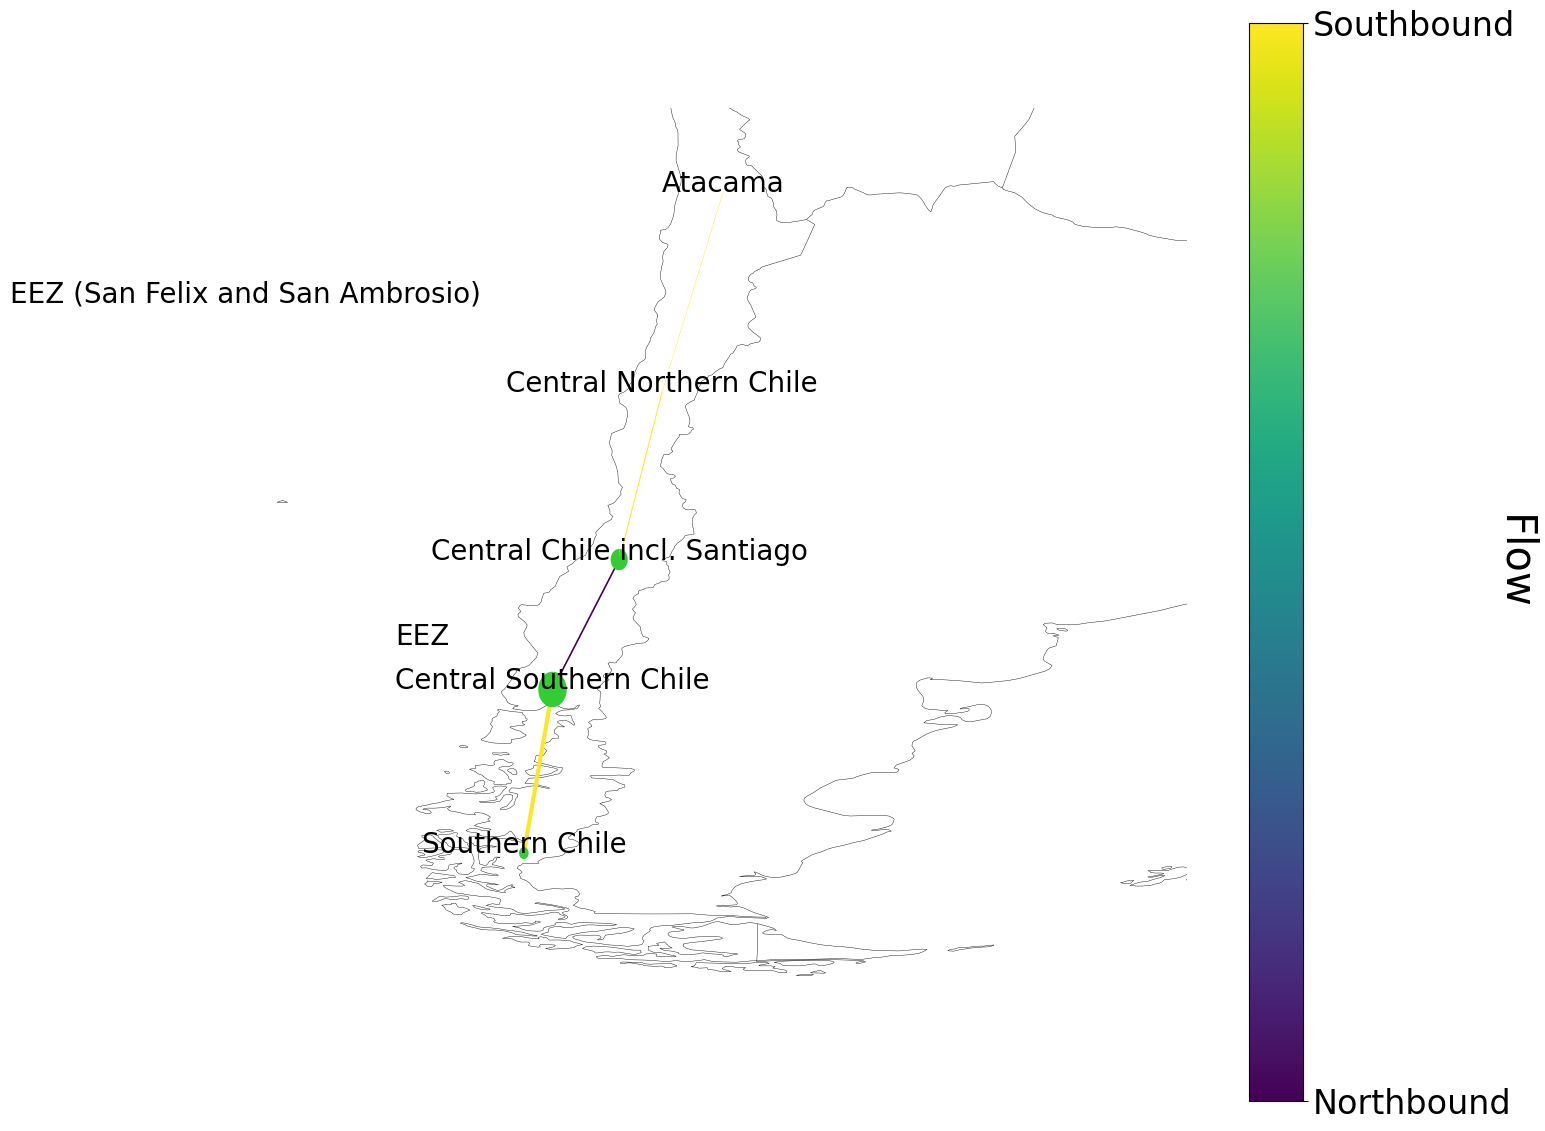

In [53]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pypsa.plot import add_legend_patches
import matplotlib.colors as mcolors

# Summer Snapchat
time_snapshot = "2013-07-01 21:00:00"
s = n.generators_t.p.loc[time_snapshot].groupby([n.generators.bus, n.generators.carrier]).sum().div(1e3)

# Define Albers Equal Area projection centered on Chile
central_lon = -71.0  # Longitude of Chile's center
central_lat = -35.0  # Adjusted latitude of Chile's center to be more south
albers = ccrs.AlbersEqualArea(central_longitude=central_lon, central_latitude=central_lat)

# Create the figure and axis
fig = plt.figure(figsize=(16, 14))  # Adjust the figure size as needed
ax = plt.axes(projection=albers)

link_loading =  n.links_t.p0.loc[time_snapshot]
norm = plt.Normalize(vmin=0, vmax=100)

# Plot the network with adjusted parameters
n.plot(ax=ax,
       bus_sizes=s/30000,
       link_colors=link_loading,
       link_norm=norm,
       link_cmap="viridis",
       link_widths=n.links.p_nom_opt/1000000)
for idx, row in aggregated_points.iterrows():
    # Get the centroid of each region
    centroid = row["geometry"].centroid
    # Annotate the plot with the region's NAME_1 at its centroid
    ax.text(centroid.x, centroid.y, row['aggRegions'], fontsize=20, ha='center', transform=ccrs.PlateCarree(),zorder=10)
    
    
# Define legend patches
colors = mcolors.Normalize(vmin=0, vmax=100)(link_loading)
patches = [plt.Line2D([0], [0], marker='o', color='w', markersize=10,
                      markerfacecolor=c, label=f'{value:.2f}') for c, value in zip(colors, link_loading)]


# Plot the boundaries of the aggregated regions with a specified line width
aggregated_regions.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Plot the base layer (Chile regions) without specifying the column to use the default geometry
aggregated_regions.plot(ax=ax, color="lightgrey",alpha=0.3,zorder=5)

# Plot the boundaries of the aggregated regions with a specified line width
aggregated_regions.boundary.plot(ax=ax, color="black", linewidth=0.5,alpha=0.2)



 # Change the filename and extension as neededs

# Set the extent of the plot to focus on Chile  
ax.set_extent([-80, -60, -60, -20], crs=ccrs.PlateCarree())# Adjust the extent as needed




# Add colorbar
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=ax, orientation='vertical')
cbar.set_label('Flow', rotation=270, labelpad=15, fontsize=30)  # Adjust fontsize as needed

# Remove tick labels
ax.set_xticks([])
ax.set_yticks([])

# Add Southbound and Northbound labels
cbar.set_ticklabels(['Northbound', 'Southbound'],fontsize=24)
cbar.set_ticks([0,  100])
plt.savefig('./Grafiken/Network_Witer.png') 
# Show the plot
plt.show()

### Dispatch figure

In [ ]:
time="2013-7"
p_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().div(1e3)
    
if not n.storage_units.empty:
        sto = n.storage_units_t.p.groupby(n.storage_units.carrier, axis=1).sum().div(1e3)
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)
    
fig, ax = plt.subplots(figsize=(15, 8))

color = {
    'battery storage': 'blue', 
    'hydrogen storage underground': 'orange',
    
    'HVAC': 'green', 
    'Biomass': 'red',
    'Coal': 'black',
    'Gas': 'grey',
    'Hydro': 'cyan',
    'Oil': 'brown',
    'Petcoke': 'lightgrey',
    'offwind': 'cyan',
    'onwind': 'royalblue',
    'solar': 'gold'
    
}
    
    
    
p_by_carrier.where(p_by_carrier>0).loc[time].plot.area(
        ax=ax,
        linewidth=0,
        color=color,
    )
    
    
    
n.loads_t.p_set.sum(axis=1).loc[time].div(1e3).plot(ax=ax, c='k')

plt.legend(loc=(1.05,0))
ax.set_ylabel("GW")
ax.set_ylim(-10, 20)


### Sensitivity Analysis

In [63]:
def system_cost(n):
   tsc = n.statistics.capex() +  n.statistics.capex().fillna(0)
   return tsc.droplevel(0).div(1e6)

In [64]:
n.storage_units.carrier

StorageUnit
Southern Chile battery storage                                            battery storage
Atacama battery storage                                                   battery storage
Central Chile incl. Santiago battery storage                              battery storage
Central Northern Chile battery storage                                    battery storage
Central Southern Chile battery storage                                    battery storage
Southern Chile hydrogen storage underground                  hydrogen storage underground
Atacama hydrogen storage underground                         hydrogen storage underground
Central Chile incl. Santiago hydrogen storage underground    hydrogen storage underground
Central Northern Chile hydrogen storage underground          hydrogen storage underground
Central Southern Chile hydrogen storage underground          hydrogen storage underground
Name: carrier, dtype: object

In [65]:
%%capture
# Initialize the dictionary with None values for each limit
# Initialize an empty DataFrame to store the results
columns = ["Limit", "System Cost"]
sensitivity_df = pd.DataFrame(columns=columns)
results_df = pd.DataFrame(columns=columns)
# Loop over each limit value
for limit in [200000,15000,10000,5000,2500,1000,500]:
        # Set the 'nom_max_solar' for each region
        n.buses.loc["Atacama", "nom_max_solar"] = limit
        n.buses.loc["Central Chile incl. Santiago", "nom_max_solar"] = limit
        n.buses.loc["Central Northern Chile", "nom_max_solar"] = limit
        n.buses.loc["Central Southern Chile", "nom_max_solar"] = limit
        n.buses.loc["Southern Chile", "nom_max_solar"] = limit
        
        # Nom Max for Storage
        n.buses.loc["Atacama", "nom_max_battery"] = 2000
        n.buses.loc["Atacama", "hydrogen_storage_underground"] = 2000

        n.buses.loc["Central Chile incl. Santiago", "nom_max_battery"] =  2000
        n.buses.loc["Central Chile incl. Santiago", "hydrogen_storage_underground"] =  2000
        
        n.buses.loc["Central Northern Chile", "nom_max_battery"] =  2000
        n.buses.loc["Central Northern Chile", "hydrogen_storage_underground"] =  2000
        
        n.buses.loc["Central Southern Chile", "nom_max_battery"] =  2000
        n.buses.loc["Central Southern Chile", "nom_max_hydrogen_storage_underground"] =  2000
        
        n.buses.loc["Southern Chile", "nom_max_battery_storage"] =  2000
        n.buses.loc["Southern Chile", "hydrogen_storage_underground"] =  2000


        # Set the 'nom_max_wind' for each region
        n.buses.loc["Atacama", "nom_max_wind"] = 100000
        n.buses.loc["Central Chile incl. Santiago", "nom_max_wind"] = 100000
        n.buses.loc["Central Northern Chile", "nom_max_wind"] = 100000
        n.buses.loc["Central Southern Chile", "nom_max_wind"] = 100000
        n.buses.loc["Southern Chile", "nom_max_wind"] = 100000

        # Perform the optimization
        n.optimize(solver_name="gurobi")

        senesitivity = system_cost(n)
        senesitivitydf = pd.DataFrame(senesitivity)
        senesitivitydf["Solar_Limit"] = limit
        senesitivitydf.reset_index(inplace=True)
        # Concatenate the result DataFrame with the sensitivity DataFrame
        results_df = pd.concat([senesitivitydf, results_df], ignore_index=True)


DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')

DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')
DatetimeIndex(['2013-12-31 21:00:00'], dtype='datetime64[ns]', name='snapshot', freq='3H')

In [153]:
results_df[14:27]

,carrier,0,Solar_Limit,Limit,System Cost
14,Coal,0.000000e+00,1000.0,NaN,NaN
15,Gas,0.000000e+00,1000.0,NaN,NaN
16,Hydro,0.000000e+00,1000.0,NaN,NaN
17,Oil,0.000000e+00,1000.0,NaN,NaN
18,Petcoke,0.000000e+00,1000.0,NaN,NaN
19,offwind,0.000000e+00,1000.0,NaN,NaN
20,onwind,4.423920e+07,1000.0,NaN,NaN
21,solar,6.822309e+02,1000.0,NaN,NaN
22,battery storage,1.618035e+06,1000.0,NaN,NaN
23,hydrogen storage underground,2.234917e+07,1000.0,NaN,NaN


In [154]:
sensitivity_df = results_df
sensitivity_df

,carrier,0,Solar_Limit,Limit,System Cost
0,Biomass,0.000000e+00,500.0,NaN,NaN
1,Coal,0.000000e+00,500.0,NaN,NaN
2,Gas,0.000000e+00,500.0,NaN,NaN
3,Hydro,0.000000e+00,500.0,NaN,NaN
4,Oil,0.000000e+00,500.0,NaN,NaN
...,...,...,...,...,...
86,solar,1.364462e+05,200000.0,NaN,NaN
87,battery storage,1.787962e+06,200000.0,NaN,NaN
88,hydrogen storage underground,2.191355e+07,200000.0,NaN,NaN
89,AC,4.297999e+07,200000.0,NaN,NaN


In [155]:
sensitivity_df = sensitivity_df.drop("System Cost",axis=1)
sensitivity_df = sensitivity_df.drop("Limit",axis=1)

In [156]:
sensitivity_df

,carrier,0,Solar_Limit
0,Biomass,0.000000e+00,500.0
1,Coal,0.000000e+00,500.0
2,Gas,0.000000e+00,500.0
3,Hydro,0.000000e+00,500.0
4,Oil,0.000000e+00,500.0
...,...,...,...
86,solar,1.364462e+05,200000.0
87,battery storage,1.787962e+06,200000.0
88,hydrogen storage underground,2.191355e+07,200000.0
89,AC,4.297999e+07,200000.0


In [177]:
pivot_df

carrier,Solar_Limit,AC,Biomass,Coal,Gas,HVAC,Hydro,Oil,Petcoke,battery storage,hydrogen storage underground,offwind,onwind,solar
0,500.0,43.608421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.618289,22.351420,0.0,44.236917,0.000341
1,1000.0,43.606330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.618035,22.349173,0.0,44.239203,0.000682
2,2500.0,43.600805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.618563,22.344327,0.0,44.242132,0.001706
3,5000.0,43.592432,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.620848,22.338342,0.0,44.242692,0.003411
4,10000.0,43.575686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.625419,22.326372,0.0,44.243812,0.006822
5,15000.0,43.558939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.629990,22.314402,0.0,44.244931,0.010233
6,200000.0,42.979986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.787962,21.913548,0.0,44.219964,0.136446


In [157]:
sensitivity_df.rename(columns={0:"System_Cost"},inplace=True)

In [158]:
sensitivity_df = sensitivity_df.drop_duplicates(subset=['carrier', 'Solar_Limit'])
sensitivity_df

,carrier,System_Cost,Solar_Limit
0,Biomass,0.000000e+00,500.0
1,Coal,0.000000e+00,500.0
2,Gas,0.000000e+00,500.0
3,Hydro,0.000000e+00,500.0
4,Oil,0.000000e+00,500.0
...,...,...,...
86,solar,1.364462e+05,200000.0
87,battery storage,1.787962e+06,200000.0
88,hydrogen storage underground,2.191355e+07,200000.0
89,AC,4.297999e+07,200000.0


In [180]:
pivot_df = sensitivity_df.pivot(index='Solar_Limit', columns='carrier', values='System_Cost').div(1e6)
pivot_df.reset_index(inplace=True)

In [189]:
sensitivity_df
df = sensitivity_df
df

,System_Cost,Solar_Limit
carrier,,
Biomass,0.000000e+00,500.0
Coal,0.000000e+00,500.0
Gas,0.000000e+00,500.0
Hydro,0.000000e+00,500.0
Oil,0.000000e+00,500.0
...,...,...
solar,1.364462e+05,200000.0
battery storage,1.787962e+06,200000.0
hydrogen storage underground,2.191355e+07,200000.0


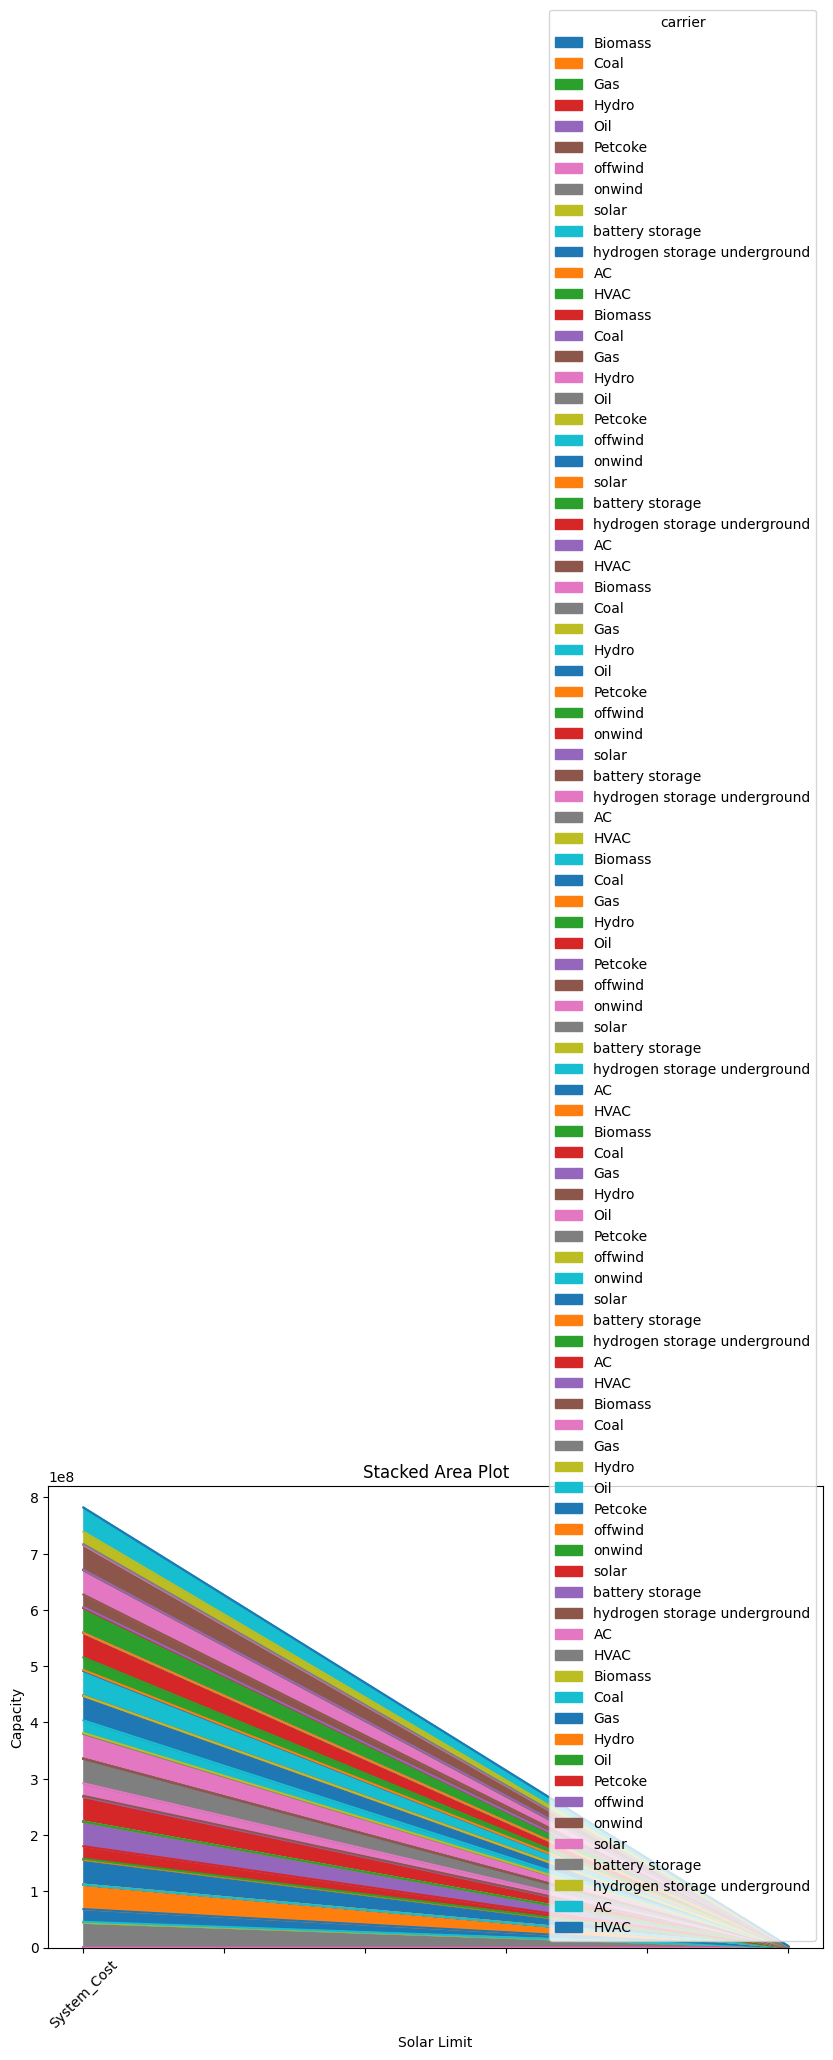

In [190]:
# Transpose DataFrame to have 'Solar_Limit' as index
df_transposed = df.transpose()

# Plot stacked area
df_transposed.plot(kind='area', stacked=True, figsize=(10, 6))
plt.title('Stacked Area Plot')
plt.xlabel('Solar Limit')
plt.ylabel('Capacity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

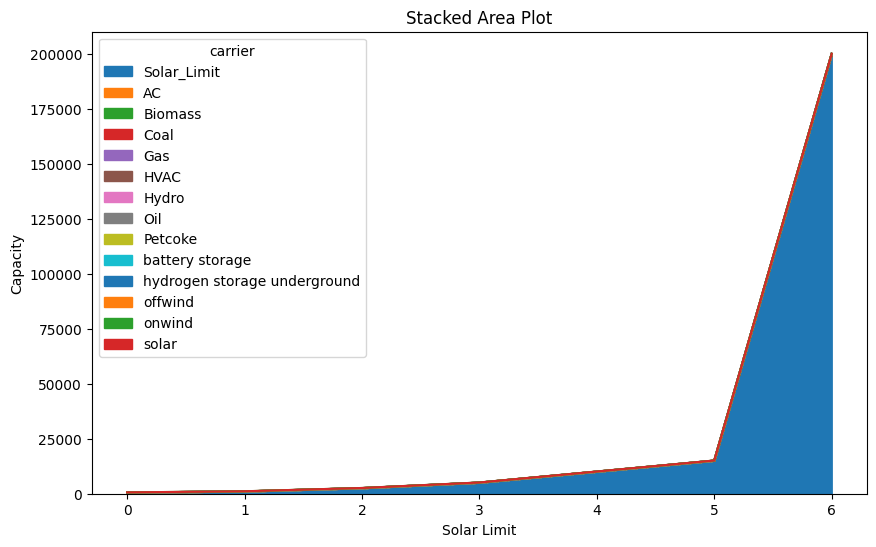

In [176]:
df.plot(kind='area', stacked=True, figsize=(10, 6))
plt.title('Stacked Area Plot')
plt.xlabel('Solar Limit')
plt.ylabel('Capacity')
plt.show()

<Axes: >

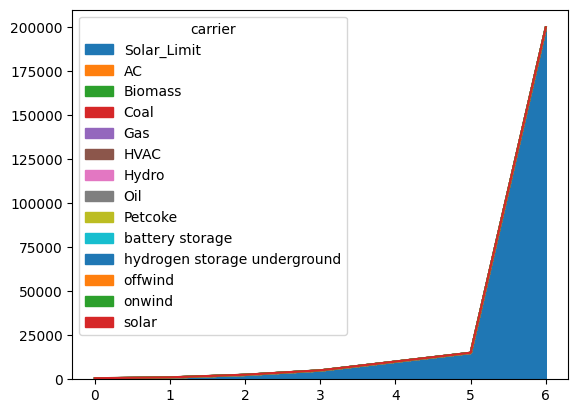

In [174]:
pivot_df.plot.area(stacked=True)

In [191]:
pivot_df

carrier,Solar_Limit,AC,Biomass,Coal,Gas,HVAC,Hydro,Oil,Petcoke,battery storage,hydrogen storage underground,offwind,onwind,solar
0,500.0,43.608421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.618289,22.351420,0.0,44.236917,0.000341
1,1000.0,43.606330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.618035,22.349173,0.0,44.239203,0.000682
2,2500.0,43.600805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.618563,22.344327,0.0,44.242132,0.001706
3,5000.0,43.592432,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.620848,22.338342,0.0,44.242692,0.003411
4,10000.0,43.575686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.625419,22.326372,0.0,44.243812,0.006822
5,15000.0,43.558939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.629990,22.314402,0.0,44.244931,0.010233
6,200000.0,42.979986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.787962,21.913548,0.0,44.219964,0.136446


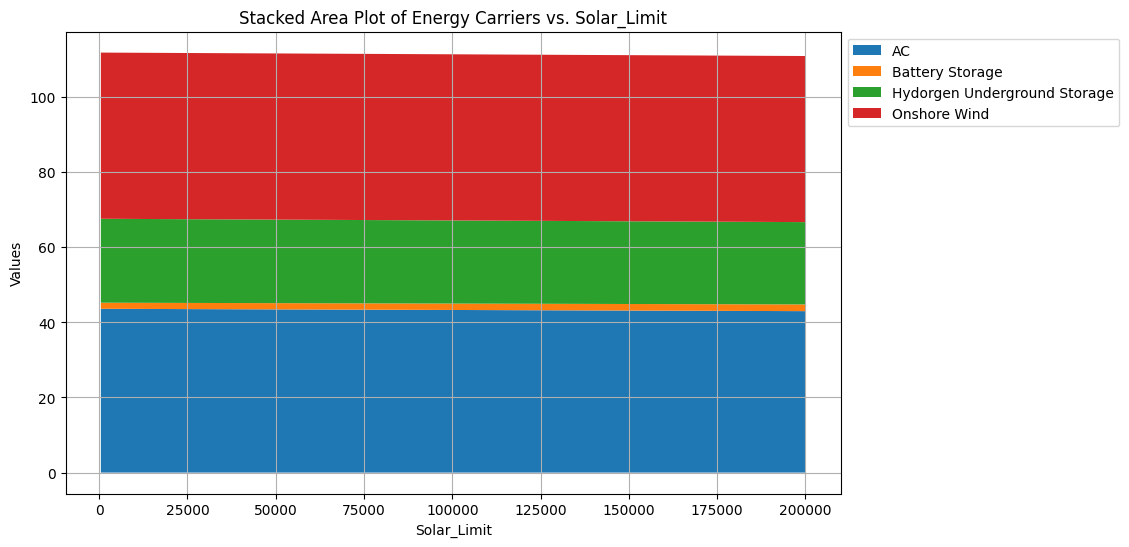

In [205]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))

plt.fill_between(pivot_df.Solar_Limit, 0,pivot_df.AC, label='AC')
plt.fill_between(pivot_df.Solar_Limit, pivot_df.AC, pivot_df["battery storage"] + pivot_df.AC,label='Battery Storage')
plt.fill_between(pivot_df.Solar_Limit, pivot_df["battery storage"] + pivot_df.AC, pivot_df.AC + pivot_df["battery storage"] + pivot_df["hydrogen storage underground"],label='Hydorgen Underground Storage')
plt.fill_between(pivot_df.Solar_Limit, pivot_df["battery storage"] + pivot_df.AC + pivot_df["hydrogen storage underground"], 
                 pivot_df.AC + pivot_df["battery storage"] + pivot_df["hydrogen storage underground"] + pivot_df["onwind"],label='Onshore Wind')



plt.xlabel('Solar_Limit')
plt.ylabel('Values')
plt.title('Stacked Area Plot of Energy Carriers vs. Solar_Limit')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()


In [ ]:
plt.fill_between(pivot_df.Solar_Limit, pivot_df.AC  pivot_df["battery storage"], pivot_df.AC + pivot_df.Biomass + pivot_df.Coal, label='Hydrogen Underground Storage',label='AC')
plt.fill_between(pivot_df.Solar_Limit, pivot_df.onwind, label='Onwind')
plt.fill_between(pivot_df.Solar_Limit, pivot_df.AC + pivot_df["battery storage"], label='Battery Storage')
plt.fill_between(pivot_df.Solar_Limit, pivot_df.AC + pivot_df["hydrogen storage underground"] + pivot_df["battery storage"], pivot_df.AC + pivot_df.Biomass + pivot_df.Coal, label='Hydrogen Underground Storage')

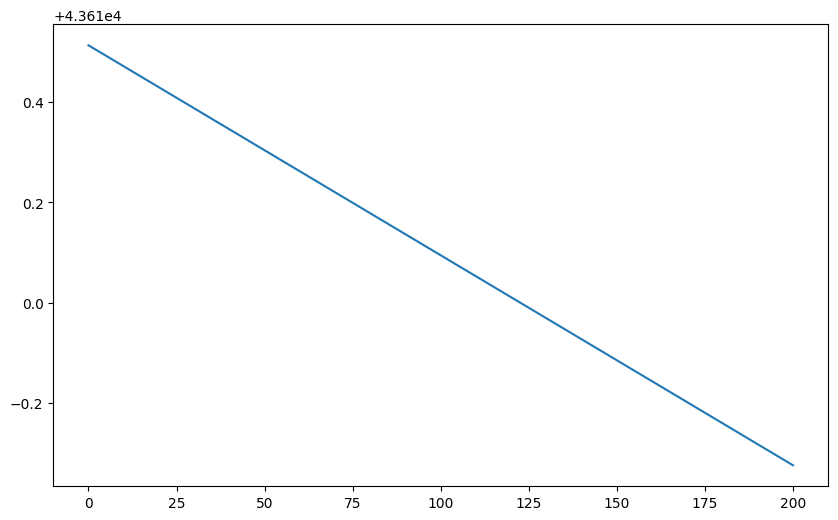

In [130]:
# Plotting
plt.figure(figsize=(10, 6))

plt.plot(pivot_df.Solar_Limit, pivot_df.AC, label='AC')


In [ ]:
plt.plot(Solar_Limit, biomass, label='Biomass')
plt.plot(Solar_Limit, coal, label='Coal')
plt.plot(Solar_Limit, gas, label='Gas')
plt.plot(Solar_Limit, hvac, label='HVAC')
plt.plot(Solar_Limit, hydro, label='Hydro')
plt.plot(Solar_Limit, oil, label='Oil')
plt.plot(Solar_Limit, petcoke, label='Petcoke')
plt.plot(Solar_Limit, battery_storage, label='Battery Storage')
plt.plot(Solar_Limit, hydrogen_storage_underground, label='Hydrogen Storage Underground')
plt.plot(Solar_Limit, offwind, label='Offwind')
plt.plot(Solar_Limit, onwind, label='Onwind')
plt.plot(Solar_Limit, solar, label='Solar')

plt.xlabel('Solar_Limit')
plt.ylabel('Values')
plt.title('Energy Carrier vs. Solar_Limit')
plt.legend()
plt.grid(True)
plt.show()

In [121]:
# Plot the DataFrame
pivot_df.plot.scatter()
plt.legend(frameon=False, loc=(1.05, 0))
plt.show()

TypeError: PlotAccessor.scatter() missing 2 required positional arguments: 'x' and 'y'

In [362]:
n.add("Carrier",
    "ac",
    color="cyan")

n.add("Carrier",
    "ac",
    color="hvac")

AssertionError: Failed to add Carrier component ac because there is already an object with this name in carriers

In [364]:
pivot_df.set_index('carrier', inplace=True)
df.plot.area(
    stacked=True,
    linewidth=0,
    color=pivot_df.columns.lower()map(n.carriers.color),
    figsize=(4, 4),
    xlim=(0, 150),
    xlabel=r"CO$_2$ emissions [Mt/a]",
    ylabel="System cost [bn€/a]",
    ylim=(0, 100),
)
plt.legend(frameon=False, loc=(1.05, 0))

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2097386836.py, line 5)

In [260]:
sensitivity_df = sensitivity_df.rename(columns={"0":"System_Cost"},inplace=True)

In [261]:
sensitivity_df

In [258]:
unstacked_df = sensitivity_df.pivot(index='Solar_Limit', columns='carrier',value="System_Cost")
unstacked_df

TypeError: DataFrame.pivot() got an unexpected keyword argument 'value'

In [240]:
df.map(n.carriers.color)

TypeError: the first argument must be callable

ValueError: Invalid color nan

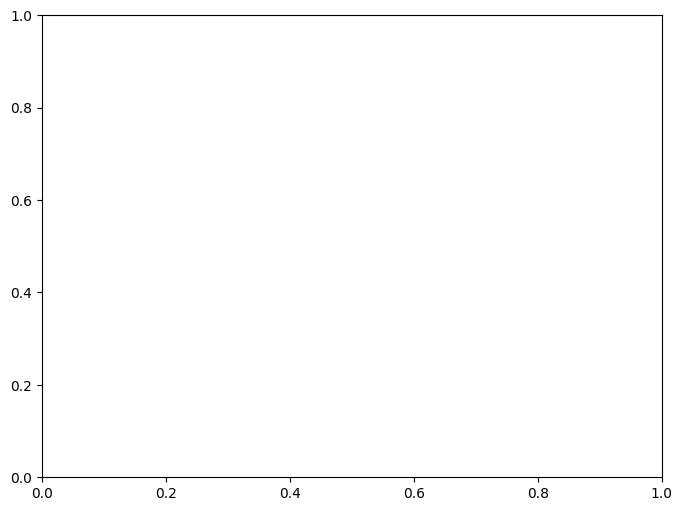

In [238]:
df = pd.DataFrame(sensitivity_df)
df.set_index('carrier', inplace=True)

# Plot the graph
ax = df.plot.area(
    stacked=True,
    linewidth=0,
    figsize=(8, 6),
    xlim=(0, 150),
    xlabel=r"Solar Limit [units]",
    ylabel="System cost [bn€/a]",
    ylim=(0, 100),
    color=df.columns.map(n.carriers.color),
    alpha=0.7
)

plt.legend(frameon=False, loc=(1.05, 0))
plt.show()

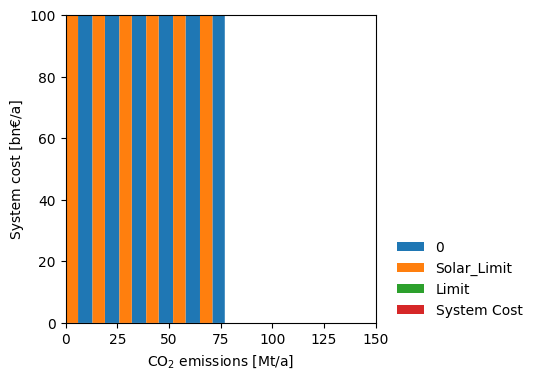

In [193]:
sensitivity_df.plot.area(
    stacked=True,
    linewidth=0,
    figsize=(4, 4),
    xlim=(0, 150),
    xlabel=r"CO$_2$ emissions [Mt/a]",
    ylabel="System cost [bn€/a]",
    ylim=(0, 100),
)
plt.legend(frameon=False, loc=(1.05, 0))

AttributeError: You are calling a geospatial method on the GeoDataFrame, but the active geometry column ('0') is not present. 
There are columns with geometry data type (['geometry']), and you can either set one as the active geometry with df.set_geometry("name") or access the column as a GeoSeries (df["name"]) and call the method directly on it.

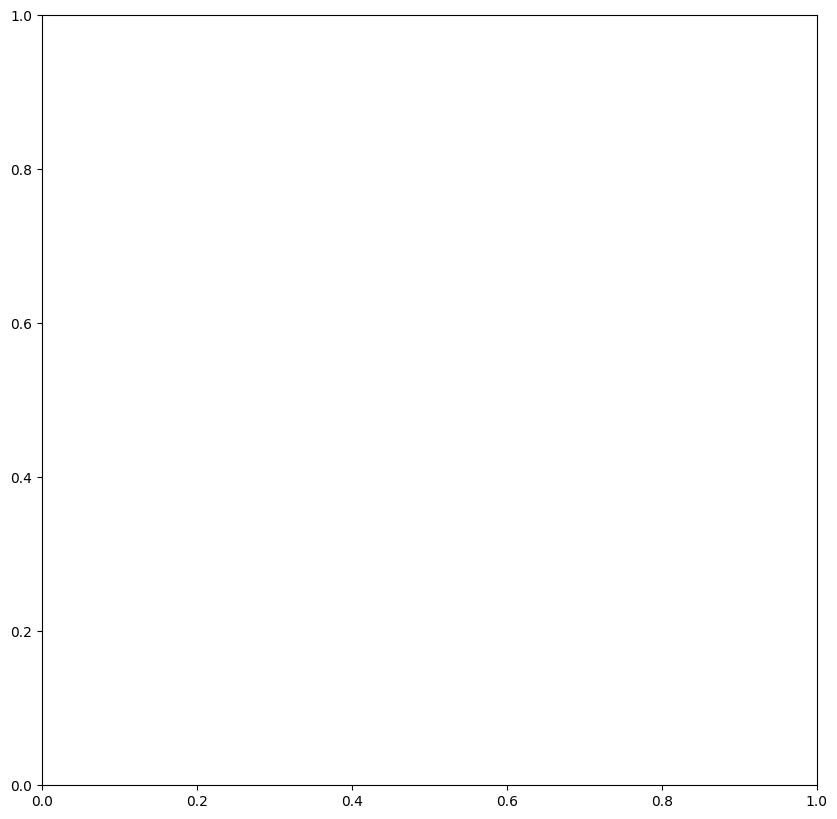

In [159]:
# Convert buses to a GeoDat
aggregated_points
# aFrame after the loop
gdf_buses = gpd.GeoDataFrame(n.buses, geometry=gpd.points_from_xy(n.buses.x, n.buses.y))
# Create a figure and axis object
fig, ax = plt.subplots(figsize=(10, 10))

# Extract x and y coordinates from the GeoDataFrame
x = aggregated_points.geometry.x
y = aggregated_points.geometry.y

# Use Matplotlib's scatter plot for more direct control over markersize
# Here, 'scaled_population' is used directly as sizes for the markers
# Ensure 'scaled_population' is scaled appropriately as discussed before
ax.scatter(x, y, s=aggregated_points['percentage']**2/4, color='red',zorder=3,alpha=0.4)

# Plot the rest of your layers as before
aggregated_regions.boundary.plot(ax=ax, color="red", linewidth=0.5, alpha=0.2)
aggregated_regions.plot(ax=ax, color="lightgrey", alpha=0.6)


# Plot the boundaries of the aggregated regions with a specified line width
aggregated_regions.boundary.plot(ax=ax, color="black", linewidth=0.5)

selected_countries.plot(ax=ax, color="lightgrey", alpha=0.4)

# Plot the base layer (Chile regions) without specifying the column to use the default geometry
aggregated_regions.plot(ax=ax, color="lightgrey",alpha=0.2)

# Plot the boundaries of the aggregated regions with a specified line width
aggregated_regions.boundary.plot(ax=ax, color="black", linewidth=0.5,alpha=0.2)

# Ensure pwp_chile GeoDataFrame is in the same CRS as aggregated_regions
pwp_chile = pwp_chile.to_crs(aggregated_points.crs)

for idx, row in aggregated_points.iterrows():
    # Get the centroid of each region
    centroid = row["geometry"]
    # Annotate the plot with the region's NAME_1 at its centroid
    ax.text(row["longitude"], row['latitude'],row['aggRegions'], fontsize=10, ha='left')

# Plot pwp_chile with size based on estimated generation and color based on primary fuel
pwp_chile.plot(
    ax=ax,
    column="primary_fuel",
    markersize=pwp_chile['estimated_generation_gwh_2017']/10,  # Adjust as necessary
    legend=True,
    legend_kwds={'title': 'Primary Fuel', 'loc': 'upper left'},
    alpha=0.8
    # Add a legend for primary_fuel categories
    # Color map for primary_fuel categories, adjust as needed
)
# Hide the x and y ticks and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.savefig('./Grafiken/selected_countries_mapMap_Chile.jpg', format='jpg', dpi=300)


plt.show()